### Imports

In [1]:
from fundus_dataset import AugmentPair, FundusVesselDataset, CenterCropPair
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torch.utils.data import random_split


### Testing the Dataset

In [2]:
# -------------------------
# Paths
# -------------------------

img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

# -------------------------
# Dataset
# -------------------------

train_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

val_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=CenterCropPair(crop_size=(512, 512)),  # or ResizePair
)

# We need this to find which indices to split the dataset into train and validation
num_samples = len(train_full)

# Set to None to use the whole dataset
sample_size = 32

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(num_samples, generator=generator).tolist()

# Globally restrict dataset size first
if sample_size is not None:
    sample_size = min(sample_size, num_samples)
    indices = indices[:sample_size]

train_size = int(0.8 * len(indices))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

# Print out number of samples in train and validation
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# -------------------------
# Debug shape check
# -------------------------

images, masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Images dtype:", images.dtype)
print("Masks dtype:", masks.dtype)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))

print("Val Images shape:", val_images.shape)
print("Val Masks shape:", val_masks.shape)
print("Val Images dtype:", val_images.dtype)
print("Val Masks dtype:", val_masks.dtype)
print("Val Image min/max:", val_images.min().item(), val_images.max().item())
print("Val Mask unique values:", torch.unique(val_masks))


Train dataset size: 25
Validation dataset size: 7


Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 1, 512, 512])
Images dtype: torch.float32
Masks dtype: torch.float32
Image min/max: 0.0 1.0
Mask unique values: tensor([0., 1.])
Val Images shape: torch.Size([7, 3, 512, 512])
Val Masks shape: torch.Size([7, 1, 512, 512])
Val Images dtype: torch.float32
Val Masks dtype: torch.float32
Val Image min/max: 0.0 1.0
Val Mask unique values: tensor([0., 1.])


### Matplotlib to test out the DataLoader

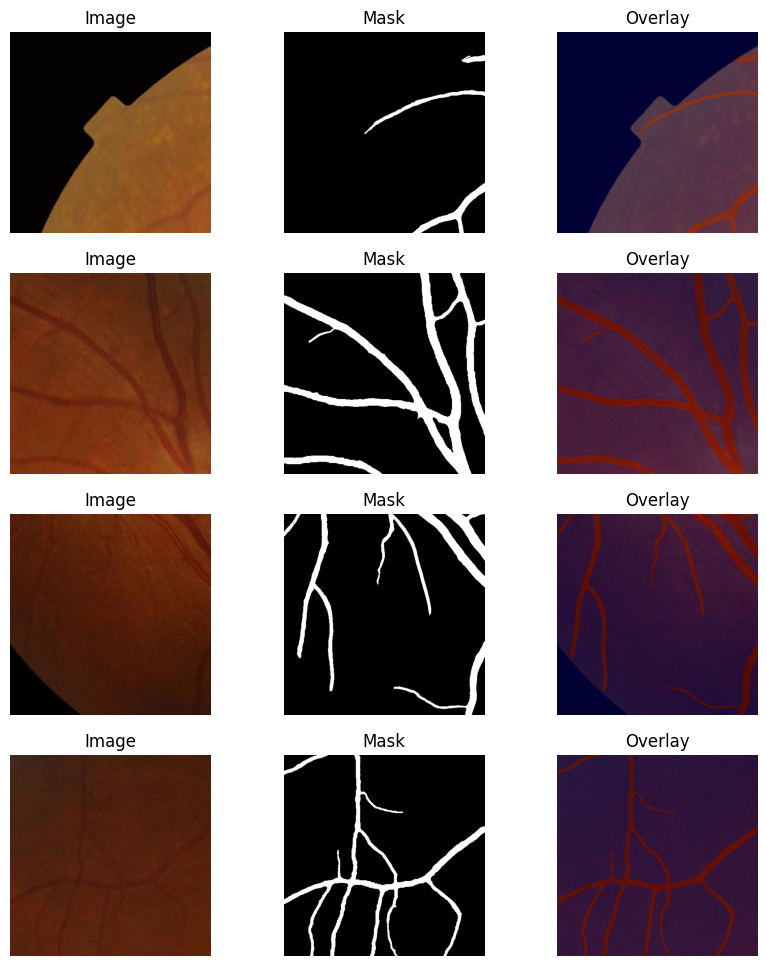

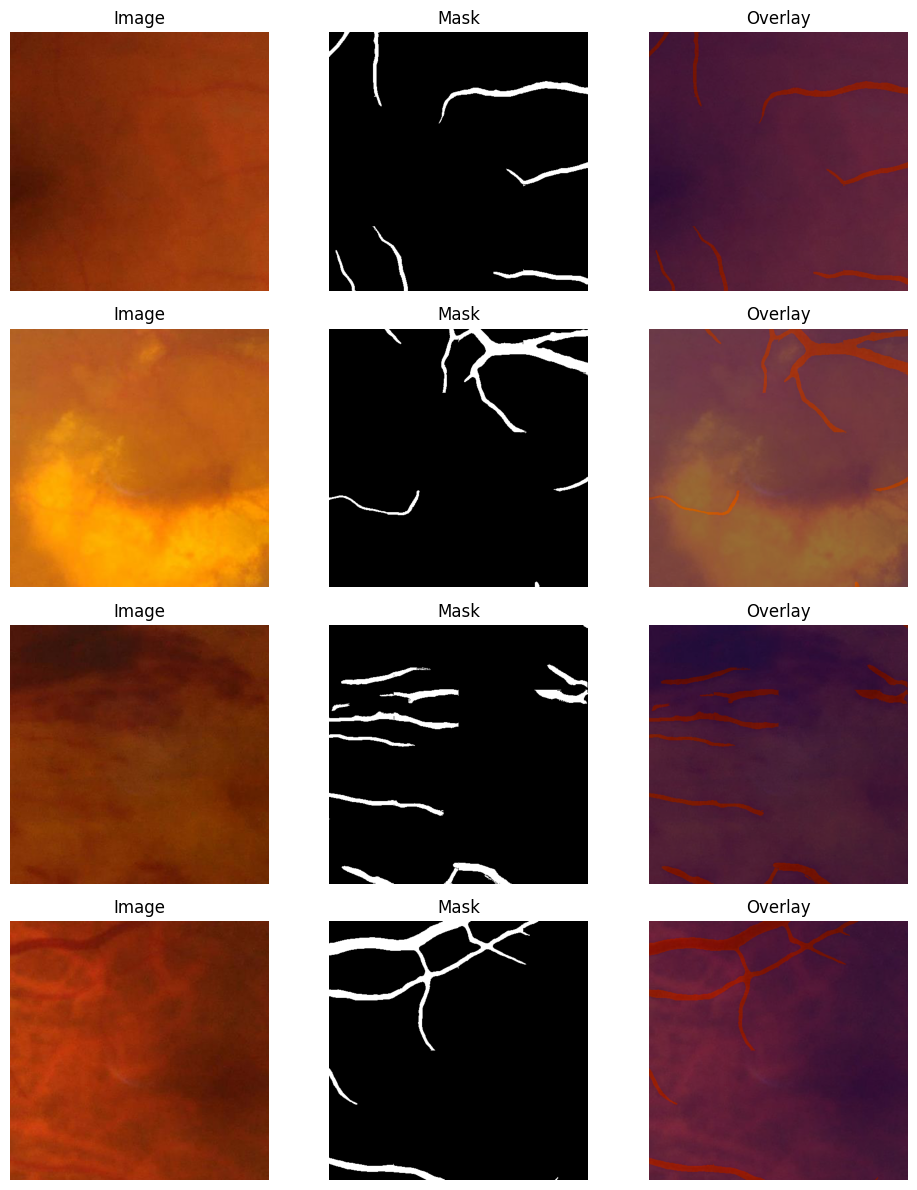

In [3]:
from matplotlib import pyplot as plt

def plot_images(images, masks): 
    fig, axes = plt.subplots(4, 3, figsize=(10, 12))

    for i in range(4):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        mask = masks[i].squeeze(0).cpu().numpy()

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(img)
        axes[i, 2].imshow(mask, cmap="jet", alpha=0.4)
        axes[i, 2].set_title("Overlay")
        axes[i, 2].axis("off")

# Plot the training images and masks
plot_images(images, masks)

# Plot the validation images and masks
plot_images(val_images, val_masks)

plt.tight_layout()
plt.show()

### U-Net Training Code

In [ ]:
from monai.networks.nets import UNet
from monai.losses import DiceLoss, SoftclDiceLoss
from monai.metrics import DiceMetric
from safetensors.torch import save_model
from datetime import datetime
import torch.nn as nn
import torch
import os
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 3

dice_loss = DiceLoss(sigmoid=True)
cldice_loss = SoftclDiceLoss()
bce_loss = nn.BCEWithLogitsLoss()
hard_dice_metric = DiceMetric(include_background=True, reduction="mean")

w_dice, w_bce, w_cldice = 0.4, 0.4, 0.2

# -------------------------
# Results Directory
# -------------------------

run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_dir = os.path.join("results", run_timestamp)
os.makedirs(run_dir, exist_ok=True)

best_model_path = os.path.join(run_dir, "best_model.safetensors")
history_path = os.path.join(run_dir, "history.json")
best_val_hard_dice = float("-inf")

# -------------------------
# Training History
# -------------------------
history = []

for epoch in range(epochs):
    # -------------------------
    # Train
    # -------------------------
    model.train()

    total_loss = 0.0
    train_dice_loss_sum = 0.0
    train_bce_loss_sum = 0.0
    train_cldice_loss_sum = 0.0
    samples = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(images)

        # Compute losses
        d_loss = dice_loss(logits, masks)
        b_loss = bce_loss(logits, masks)

        # MONAI SoftclDiceLoss is implemented for multi-class inputs [B, C, H, W]
        # and assumes channel 0 = background, channel 1 = foreground. Internally,
        # it slices `[:, 1:, ...]` and computes clDice only on foreground channels.
        #
        # Our model outputs binary segmentation logits [B,1,H,W] (foreground only),
        # so we explicitly construct a 2-channel representation:
        #   foreground probability = p
        #   background probability = 1 - p
        #
        # This does not add new information—it just makes the implicit background
        # probability explicit so the MONAI implementation works correctly.
        probs = torch.sigmoid(logits)
        masks = masks.float()
        probs_2c = torch.cat([1.0 - probs, probs], dim=1)
        masks_2c = torch.cat([1.0 - masks, masks], dim=1)
        c_loss = cldice_loss(masks_2c, probs_2c)


        loss = w_dice * d_loss + w_bce * b_loss + w_cldice * c_loss

        # Backward pass
        loss.backward()

        # Gradient descent
        optimizer.step()

        # Update metrics
        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        train_dice_loss_sum += d_loss.item() * batch_size
        train_bce_loss_sum += b_loss.item() * batch_size
        train_cldice_loss_sum += c_loss.item() * batch_size
        samples += batch_size

    # Compute average losses at end of epoch
    avg_train_loss = total_loss / samples
    avg_train_dice_loss = train_dice_loss_sum / samples
    avg_train_bce_loss = train_bce_loss_sum / samples
    avg_train_cldice_loss = train_cldice_loss_sum / samples

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_dice_loss = 0.0
    val_bce_loss = 0.0
    val_cldice_loss = 0.0
    val_samples = 0

    hard_dice_metric.reset()

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            d_loss = dice_loss(logits, masks)
            b_loss = bce_loss(logits, masks)

            # MONAI SoftclDiceLoss is implemented for multi-class inputs [B, C, H, W]
            # and assumes channel 0 = background, channel 1 = foreground. Internally,
            # it slices `[:, 1:, ...]` and computes clDice only on foreground channels.
            #
            # Our model outputs binary segmentation logits [B,1,H,W] (foreground only),
            # so we explicitly construct a 2-channel representation:
            #   foreground probability = p
            #   background probability = 1 - p
            #
            # This does not add new information—it just makes the implicit background
            # probability explicit so the MONAI implementation works correctly.
            probs = torch.sigmoid(logits)
            masks = masks.float()
            probs_2c = torch.cat([1.0 - probs, probs], dim=1)
            masks_2c = torch.cat([1.0 - masks, masks], dim=1)
            c_loss = cldice_loss(masks_2c, probs_2c)

            loss = w_dice * d_loss + w_bce * b_loss + w_cldice * c_loss

            batch_size = images.size(0)
            val_loss += loss.item() * batch_size
            val_dice_loss += d_loss.item() * batch_size
            val_bce_loss += b_loss.item() * batch_size
            val_cldice_loss += c_loss.item() * batch_size
            val_samples += batch_size

            preds = (probs > 0.5).float()

            hard_dice_metric(y_pred=preds, y=masks)

    avg_val_loss = val_loss / val_samples
    avg_val_dice_loss = val_dice_loss / val_samples
    avg_val_bce_loss = val_bce_loss / val_samples
    avg_val_cldice_loss = val_cldice_loss / val_samples
    val_hard_dice = hard_dice_metric.aggregate().item()

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "train_dice_loss": avg_train_dice_loss,
        "train_bce_loss": avg_train_bce_loss,
        "train_cldice_loss": avg_train_cldice_loss,
        "val_loss": avg_val_loss,
        "val_dice_loss": avg_val_dice_loss,
        "val_bce_loss": avg_val_bce_loss,
        "val_cldice_loss": avg_val_cldice_loss,
        "val_hard_dice": val_hard_dice,
    })

    if val_hard_dice > best_val_hard_dice:
        best_val_hard_dice = val_hard_dice
        save_model(model, best_model_path)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"train_loss={avg_train_loss:.4f} | "
        f"val_loss={avg_val_loss:.4f} | "
        f"val_cldice_loss={avg_val_cldice_loss:.4f} | "
        f"val_hard_dice={val_hard_dice:.4f}"
    )

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print(f"Saved best model to: {best_model_path}")
print(f"Saved training history to: {history_path}")

Epoch 1/3 | train_loss=0.8194 | val_loss=0.8614 | val_cldice_loss=0.8276 | val_hard_dice=0.0832
Epoch 2/3 | train_loss=0.8112 | val_loss=0.8494 | val_cldice_loss=0.7968 | val_hard_dice=0.0823
Epoch 3/3 | train_loss=0.8001 | val_loss=0.8416 | val_cldice_loss=0.7736 | val_hard_dice=0.0825
Saved best model to: results/2026-04-30_08-56-07/best_model.safetensors
Saved training history to: results/2026-04-30_08-56-07/history.json


### Weighted Loss Graphs for Both Train and Validation